# H7 — Biais de discrimination vs taille du modèle

**Hypothèse exploratoire :** « Plus un modèle est grand (en nombre de paramètres), plus il a
absorbé de stéréotypes culturels, et donc plus son score de discrimination est élevé. »

> **Limite méthodologique importante :** Les tailles réelles en milliards de paramètres ne sont
> pas toutes publiquement disponibles (Qwen3.7-max est non divulgué). L'axe X est donc
> **ordinal** (rang de taille, `SIZE_MAP`), et non quantitatif. Les tendances observées
> ne peuvent pas être interprétées comme des relations linéaires continues. Les résultats
> sont partiels : tous les modèles n'ont pas toutes les métriques (comparatif / IAT parfois absents).


In [1]:
import sys
sys.path.insert(0, '..')
from utils.analysis import *

set_style()

df      = charger_behavioral()
iat     = charger_iat()
single  = df[df.eval_mode == 'single']
comp    = df[df.eval_mode == 'comparative'].dropna(subset=['chose_majorite'])
MODELES = modeles_tries(df)
print("Modèles (triés par rang de taille):", MODELES)
print("Rangs SIZE_MAP:", {m: SIZE_MAP.get(m, '?') for m in MODELES})


Modèles (triés par rang de taille): ['Mistral-Nemo-Novita', 'Qwen3.6-27B-FP8', 'Gemma-4-31B-it', 'Qwen3.7-max-Novita']
Rangs SIZE_MAP: {'Mistral-Nemo-Novita': 1, 'Qwen3.6-27B-FP8': 2, 'Gemma-4-31B-it': 3, 'Qwen3.7-max-Novita': 4}


## Construction du tableau métriques × modèle

Cinq définitions du « score de discrimination » sont calculées pour chaque modèle.
Un `NaN` indique que la donnée est absente ou insuffisante pour ce modèle.


In [2]:
rows = []
for m in MODELES:
    rang = SIZE_MAP.get(m, np.nan)

    # ── Métrique 1 : Préférence majorité comparatif = P(fr choisi) - 0.5 ──
    comp_m = comp[comp.model == m]
    if len(comp_m):
        pref_maj = comp_m['chose_majorite'].mean() - 0.5
    else:
        pref_maj = np.nan

    # ── Métrique 2 : Écart ethnique single = max - min P(accepter) ─────────
    s_m = single[single.model == m]
    p_eth = {eth: s_m[s_m.condition == eth]['accepte'].mean() for eth in ETHNIES}
    vals = [v for v in p_eth.values() if not np.isnan(v)]
    ecart_eth = max(vals) - min(vals) if len(vals) >= 2 else np.nan

    # ── Métrique 3 : Ampleur du basculement (single -> comparatif) ────────
    basculements = []
    for eth in MIN:
        fs = fav_single(single, m, eth)
        fc = fav_comp(comp, m, eth)
        if not (np.isnan(fs) or np.isnan(fc)):
            basculements.append(fs - fc)
    basculement = np.mean(basculements) if basculements else np.nan

    # ── Métriques IAT ─────────────────────────────────────────────────────
    iat_m = iat[iat.model == m]
    score_iat_c = iat_m[iat_m.label_variant == 'variant_c']['score'].mean()
    score_iat_a = iat_m[iat_m.label_variant == 'variant_a']['score'].mean()

    rows.append({
        'Modèle':               m,
        'Rang taille':          rang,
        'Pref. maj. comp.':     round(pref_maj, 3)     if not np.isnan(pref_maj)     else np.nan,
        'Écart ethnique':       round(ecart_eth, 3)    if not np.isnan(ecart_eth)    else np.nan,
        'Ampleur basculement':  round(basculement, 3)  if not np.isnan(basculement)  else np.nan,
        'Score IAT-C':          round(score_iat_c, 3)  if not np.isnan(score_iat_c)  else np.nan,
        'Score IAT-A':          round(score_iat_a, 3)  if not np.isnan(score_iat_a)  else np.nan,
    })

metrics_df = pd.DataFrame(rows).set_index('Modèle')
display(metrics_df)


,Rang taille,Pref. maj. comp.,Écart ethnique,Ampleur basculement,Score IAT-C,Score IAT-A
Modèle,,,,,,
Mistral-Nemo-Novita,1,-0.065,0.026,-0.043,-0.620,0.059
Qwen3.6-27B-FP8,2,-0.001,0.051,-0.006,-0.843,-0.007
Gemma-4-31B-it,3,0.000,0.020,-0.015,-1.000,0.045
Qwen3.7-max-Novita,4,-0.003,0.010,0.007,-0.987,-0.348


### Variante 1 — Petits multiples (scatter par métrique)

Un sous-graphe par métrique. L'axe X est le rang ordinal de taille (`SIZE_MAP`).
Chaque point est annoté du nom du modèle. Une droite de tendance (régression linéaire)
est tracée quand au moins 2 points sont disponibles.


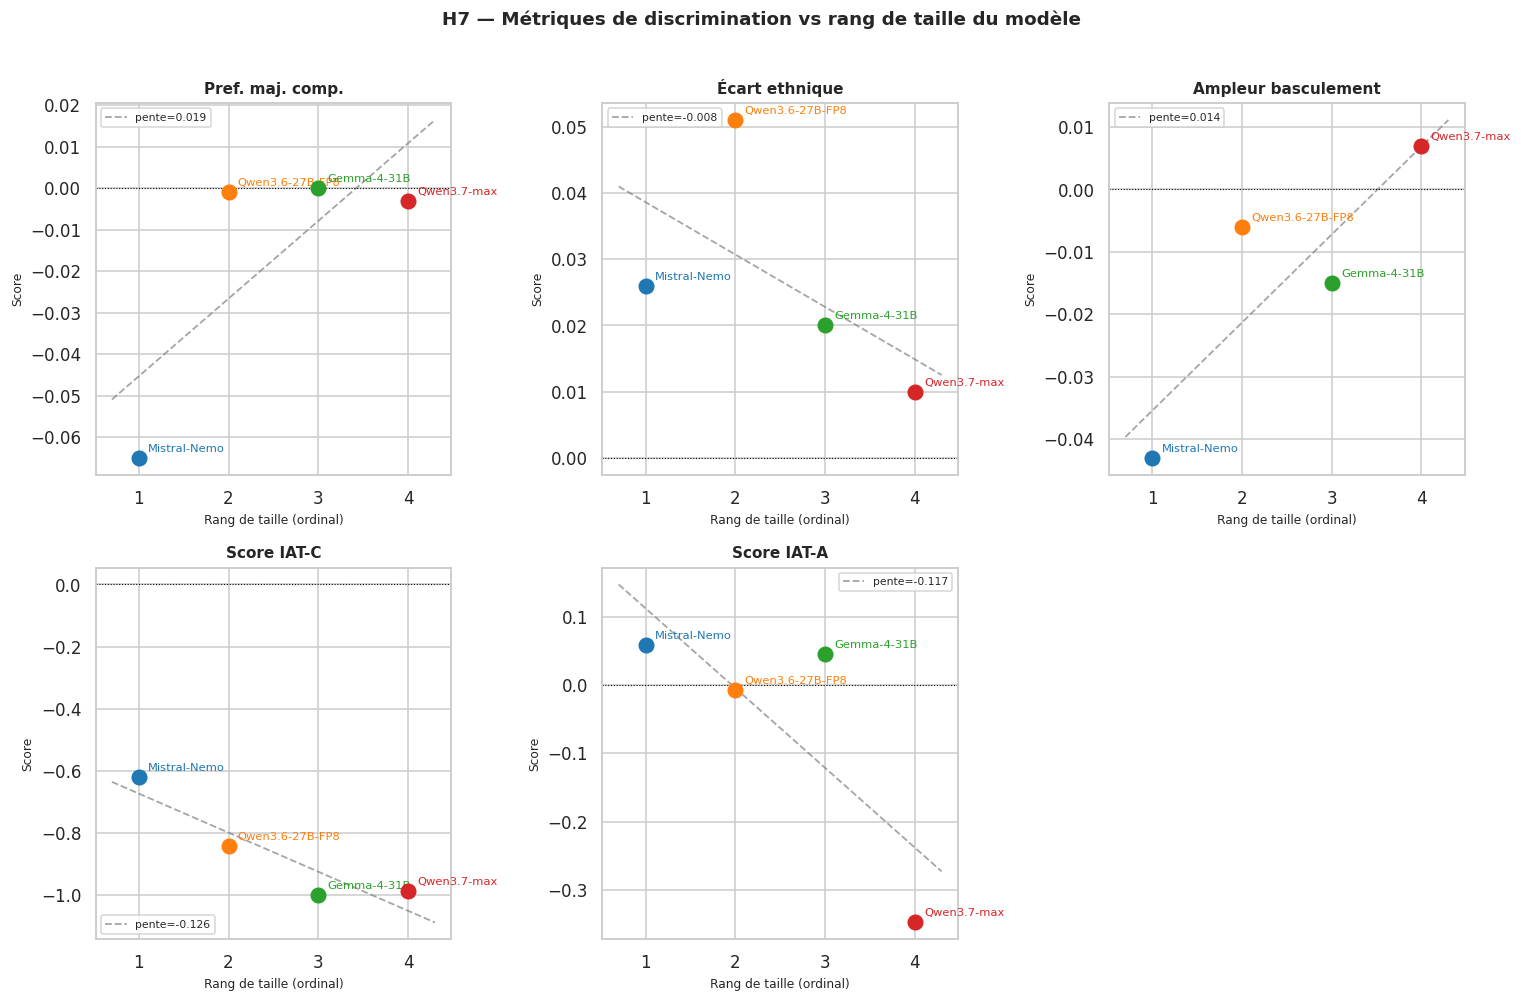

In [3]:
metric_cols = [
    'Pref. maj. comp.',
    'Écart ethnique',
    'Ampleur basculement',
    'Score IAT-C',
    'Score IAT-A',
]
n_metrics = len(metric_cols)
ncols = 3
nrows = (n_metrics + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = axes.flatten()

colors = sns.color_palette('tab10', len(MODELES))
model_color = {m: colors[i] for i, m in enumerate(MODELES)}

for idx, col in enumerate(metric_cols):
    ax = axes[idx]
    sub = metrics_df[['Rang taille', col]].dropna()

    if len(sub) == 0:
        ax.set_visible(False)
        continue

    xs = sub['Rang taille'].values
    ys = sub[col].values

    # Points
    for m_name in sub.index:
        row = metrics_df.loc[m_name]
        ax.scatter(row['Rang taille'], row[col],
                   color=model_color[m_name], s=90, zorder=3)
        ax.annotate(m_name.replace('-Novita', '').replace('-it', ''),
                    (row['Rang taille'], row[col]),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=7.5, color=model_color[m_name])

    # Droite de tendance
    if len(sub) >= 2:
        m_fit, b_fit = np.polyfit(xs, ys, 1)
        x_line = np.linspace(xs.min() - 0.3, xs.max() + 0.3, 100)
        ax.plot(x_line, m_fit * x_line + b_fit,
                '--', color='grey', linewidth=1.2, alpha=0.7, label=f'pente={m_fit:.3f}')
        ax.legend(fontsize=7, loc='best')

    ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Rang de taille (ordinal)', fontsize=8)
    ax.set_ylabel('Score', fontsize=8)
    ax.set_xticks(list(SIZE_MAP.values()))

# Masquer les axes vides
for i in range(n_metrics, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('H7 — Métriques de discrimination vs rang de taille du modèle',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Variante 2 — Métriques normalisées (z-score) superposées

Toutes les métriques sont standardisées (z-score) pour être comparables sur un même graphe.
Cela permet de voir si les métriques convergent ou divergent selon la taille du modèle.
Les colonnes avec trop peu de valeurs valides (< 2) sont exclues de la normalisation.


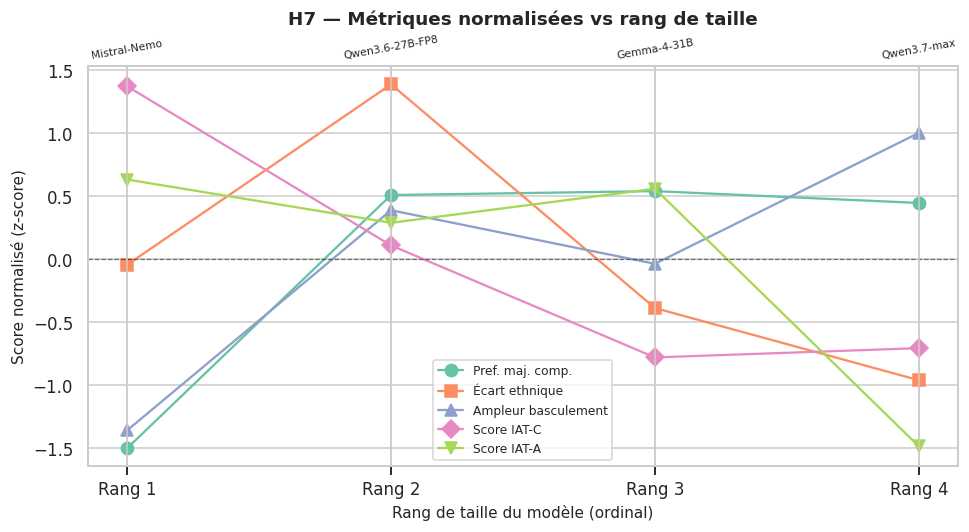

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

palette = sns.color_palette('Set2', len(metric_cols))
markers = ['o', 's', '^', 'D', 'v']

for idx, col in enumerate(metric_cols):
    sub = metrics_df[['Rang taille', col]].dropna()
    if len(sub) < 2:
        continue

    # Z-score sur les valeurs disponibles
    mu, sigma = sub[col].mean(), sub[col].std()
    if sigma == 0:
        continue
    z = (sub[col] - mu) / sigma

    ax.plot(sub['Rang taille'], z,
            marker=markers[idx % len(markers)],
            color=palette[idx], linewidth=1.5,
            markersize=8, label=col)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(list(SIZE_MAP.values()))
ax.set_xticklabels([f"Rang {v}" for v in SIZE_MAP.values()])
ax.set_xlabel('Rang de taille du modèle (ordinal)', fontsize=10)
ax.set_ylabel('Score normalisé (z-score)', fontsize=10)
ax.set_title('H7 — Métriques normalisées vs rang de taille', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='best', framealpha=0.8)

# Annotations des modèles sur l'axe X
model_by_rank = {v: k for k, v in SIZE_MAP.items()}
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(list(SIZE_MAP.values()))
ax2.set_xticklabels(
    [model_by_rank.get(v, '').replace('-Novita', '').replace('-it', '')
     for v in SIZE_MAP.values()],
    fontsize=7, rotation=10
)
ax2.tick_params(length=0)

plt.tight_layout()
plt.show()


### Variante 3 — Tableau trié par taille + heatmap

Le tableau classe les modèles du plus petit au plus grand (rang ordinal).
La heatmap visualise instantanément les niveaux relatifs de discrimination
par métrique et par modèle (valeurs brutes annotées, colorées par colonne).


Tableau métriques × modèle (trié par rang de taille croissant) :


,Rang taille,Pref. maj. comp.,Écart ethnique,Ampleur basculement,Score IAT-C,Score IAT-A
Modèle,,,,,,
Mistral-Nemo-Novita,1,-0.065,0.026,-0.043,-0.620,0.059
Qwen3.6-27B-FP8,2,-0.001,0.051,-0.006,-0.843,-0.007
Gemma-4-31B-it,3,0.000,0.020,-0.015,-1.000,0.045
Qwen3.7-max-Novita,4,-0.003,0.010,0.007,-0.987,-0.348


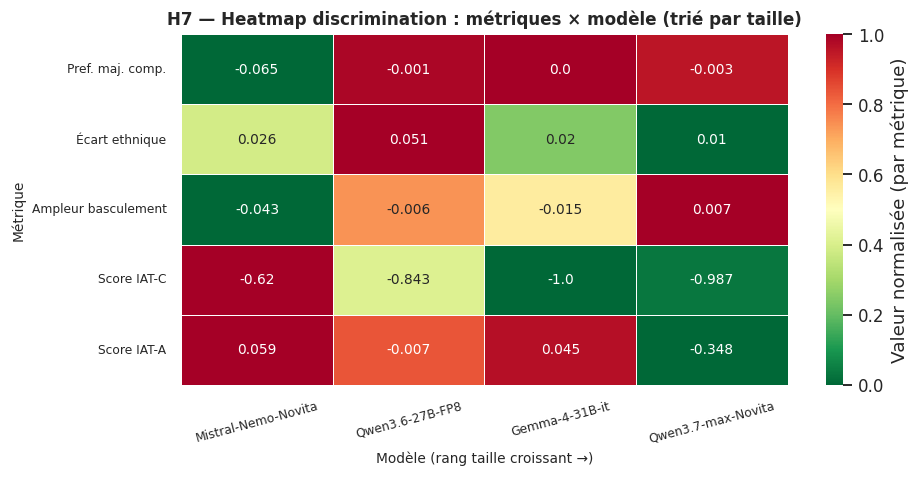

In [5]:
# Tableau trié par rang de taille
df_sorted = metrics_df.sort_values('Rang taille').copy()
print("Tableau métriques × modèle (trié par rang de taille croissant) :")
display(df_sorted)

# Heatmap : métriques × modèle
heatmap_df = df_sorted[metric_cols].T  # lignes = métriques, colonnes = modèles

fig, ax = plt.subplots(figsize=(max(8, len(MODELES) * 2.2), 4.5))

# Normalisation par ligne (métrique) pour la couleur
from sklearn.preprocessing import minmax_scale as _mms
import warnings as _w

normed = heatmap_df.copy().astype(float)
for row_label in normed.index:
    vals = normed.loc[row_label].values.astype(float)
    finite = vals[~np.isnan(vals)]
    if len(finite) >= 2:
        mn, mx = finite.min(), finite.max()
        rng = mx - mn if mx != mn else 1.0
        normed.loc[row_label] = (vals - mn) / rng
    else:
        normed.loc[row_label] = np.nan

sns.heatmap(
    normed,
    ax=ax,
    annot=heatmap_df.round(3).values,
    fmt='',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Valeur normalisée (par métrique)'},
    annot_kws={'size': 9},
    vmin=0, vmax=1,
)
ax.set_title('H7 — Heatmap discrimination : métriques × modèle (trié par taille)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Modèle (rang taille croissant →)', fontsize=9)
ax.set_ylabel('Métrique', fontsize=9)
ax.tick_params(axis='x', rotation=15, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()
